In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
BASE_DIR = Path.home() / "b200_dynamic_range_complete"

RAW_FILE = BASE_DIR / "dynamic_range_raw_measurements.csv"
AGGREGATED_FILE = BASE_DIR / "dynamic_range_aggregated_points.csv"
SUMMARY_FILE = BASE_DIR / "dynamic_range_summary.csv"

PLOTS_DIR = BASE_DIR / "plots_notebook"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("CSV brut       :", RAW_FILE)
print("CSV agrégé     :", AGGREGATED_FILE)
print("CSV résumé     :", SUMMARY_FILE)
print("Graphes        :", PLOTS_DIR)

print("\nExistence des fichiers :")
print("Brut   :", RAW_FILE.exists())
print("Agrégé :", AGGREGATED_FILE.exists())
print("Résumé :", SUMMARY_FILE.exists())

CSV brut       : /home/yousef/b200_dynamic_range_complete/dynamic_range_raw_measurements.csv
CSV agrégé     : /home/yousef/b200_dynamic_range_complete/dynamic_range_aggregated_points.csv
CSV résumé     : /home/yousef/b200_dynamic_range_complete/dynamic_range_summary.csv
Graphes        : /home/yousef/b200_dynamic_range_complete/plots_notebook

Existence des fichiers :
Brut   : True
Agrégé : True
Résumé : True


In [3]:
raw_df = pd.read_csv(RAW_FILE)
aggregated_df = pd.read_csv(AGGREGATED_FILE)
summary_df = pd.read_csv(SUMMARY_FILE)

print("Dimensions :")
print("Raw        :", raw_df.shape)
print("Aggregated :", aggregated_df.shape)
print("Summary    :", summary_df.shape)

print("\nPremières lignes du résumé :")
display(summary_df.head())

Dimensions :
Raw        : (72100, 20)
Aggregated : (6100, 17)
Summary    : (100, 15)

Premières lignes du résumé :


,frequency_hz,frequency_mhz,gain_db,rx2_min_tested_dbm,rx2_max_tested_dbm,noise_total_dbfs,noise_tone_dbfs,minimum_detectable_dbm,pmin_status,maximum_linear_dbm,pmax_status,dynamic_range_db,linear_fit_slope,linear_fit_intercept,number_of_input_points
0,100000000.0,100.0,0.0,-80.0,-20.0,-69.460477,-126.390694,-80.0,limite_basse_du_banc,-20.0,limite_haute_du_banc,60.0,0.943223,-32.392918,61
1,100000000.0,100.0,20.0,-80.0,-20.0,-64.906207,-122.531363,-80.0,limite_basse_du_banc,-28.0,mesure_valide,52.0,0.837630,-20.192771,61
2,100000000.0,100.0,40.0,-80.0,-20.0,-59.952423,-115.050399,-80.0,limite_basse_du_banc,-41.0,mesure_valide,39.0,0.752869,-2.887283,61
3,100000000.0,100.0,60.0,-80.0,-20.0,-44.310667,-99.352954,-80.0,limite_basse_du_banc,-71.0,mesure_valide,9.0,0.611191,4.540478,61
4,100000000.0,100.0,76.0,-80.0,-20.0,-31.427125,-88.863426,-80.0,limite_basse_du_banc,-71.0,mesure_valide,9.0,0.991803,45.626426,61


In [4]:
print("Colonnes du CSV brut :")
for column in raw_df.columns:
    print(" -", column)

print("\nColonnes du CSV agrégé :")
for column in aggregated_df.columns:
    print(" -", column)

print("\nColonnes du CSV résumé :")
for column in summary_df.columns:
    print(" -", column)

Colonnes du CSV brut :
 - frequency_hz
 - frequency_mhz
 - generator_frequency_hz
 - tone_offset_hz
 - gain_db
 - attenuation_db
 - generator_dbm
 - input_rx2_dbm
 - total_power_linear
 - total_power_dbfs
 - tone_power_linear
 - tone_power_dbfs
 - noise_total_power_linear
 - noise_total_dbfs
 - noise_tone_power_linear
 - noise_tone_dbfs
 - snr_db
 - peak_amplitude
 - clipping_fraction
 - detected

Colonnes du CSV agrégé :
 - frequency_hz
 - frequency_mhz
 - gain_db
 - input_rx2_dbm
 - generator_dbm
 - attenuation_db
 - total_power_dbfs
 - tone_power_dbfs
 - noise_total_dbfs
 - noise_tone_dbfs
 - median_snr_db
 - detection_probability
 - peak_amplitude
 - clipping_fraction
 - predicted_dbfs
 - compression_db
 - linear

Colonnes du CSV résumé :
 - frequency_hz
 - frequency_mhz
 - gain_db
 - rx2_min_tested_dbm
 - rx2_max_tested_dbm
 - noise_total_dbfs
 - noise_tone_dbfs
 - minimum_detectable_dbm
 - pmin_status
 - maximum_linear_dbm
 - pmax_status
 - dynamic_range_db
 - linear_fit_slope
 -

In [5]:
def find_column(dataframe, possible_names, required=True):
    """
    Cherche la première colonne existante parmi plusieurs noms possibles.
    """

    for name in possible_names:
        if name in dataframe.columns:
            return name

    if required:
        raise KeyError(
            "Aucune colonne trouvée parmi : "
            + ", ".join(possible_names)
            + "\nColonnes disponibles : "
            + ", ".join(dataframe.columns)
        )

    return None

In [6]:
SUMMARY_FREQ_COL = find_column(
    summary_df,
    ["frequency_mhz", "freq_mhz", "frequency_MHz"],
)

SUMMARY_GAIN_COL = find_column(
    summary_df,
    ["gain_db", "gain", "rx_gain_db"],
)

SUMMARY_NOISE_DBFS_COL = find_column(
    summary_df,
    [
        "noise_total_dbfs",
        "noise_dbfs",
        "noise_floor_dbfs",
        "noise_mean_dbfs",
    ],
)

SUMMARY_NOISE_TONE_DBFS_COL = find_column(
    summary_df,
    [
        "noise_tone_dbfs",
        "tone_noise_dbfs",
    ],
    required=False,
)

SUMMARY_NOISE_DBM_COL = find_column(
    summary_df,
    [
        "noise_estimated_dbm",
        "noise_dbm",
        "noise_floor_dbm",
    ],
    required=False,
)

SUMMARY_PMIN_COL = find_column(
    summary_df,
    [
        "minimum_detectable_dbm",
        "pmin_dbm",
        "minimum_input_dbm",
        "sensitivity_dbm",
    ],
)

SUMMARY_PMAX_COL = find_column(
    summary_df,
    [
        "maximum_linear_dbm",
        "pmax_dbm",
        "maximum_input_dbm",
    ],
)

SUMMARY_DYNAMIC_COL = find_column(
    summary_df,
    [
        "dynamic_range_db",
        "dynamic_db",
        "dynamics_db",
    ],
)

SUMMARY_ATTENUATION_COL = find_column(
    summary_df,
    ["attenuation_db", "attenuation"],
    required=False,
)

SUMMARY_STATUS_COL = find_column(
    summary_df,
    ["status", "state"],
    required=False,
)

SUMMARY_PMIN_STATUS_COL = find_column(
    summary_df,
    ["pmin_status"],
    required=False,
)

SUMMARY_PMAX_STATUS_COL = find_column(
    summary_df,
    ["pmax_status"],
    required=False,
)

print("Fréquence        :", SUMMARY_FREQ_COL)
print("Gain             :", SUMMARY_GAIN_COL)
print("Bruit total dBFS :", SUMMARY_NOISE_DBFS_COL)
print("Bruit tone dBFS  :", SUMMARY_NOISE_TONE_DBFS_COL)
print("Bruit dBm        :", SUMMARY_NOISE_DBM_COL)
print("Pmin             :", SUMMARY_PMIN_COL)
print("Pmax             :", SUMMARY_PMAX_COL)
print("Dynamique        :", SUMMARY_DYNAMIC_COL)
print("Statut Pmin      :", SUMMARY_PMIN_STATUS_COL)
print("Statut Pmax      :", SUMMARY_PMAX_STATUS_COL)

Fréquence        : frequency_mhz
Gain             : gain_db
Bruit total dBFS : noise_total_dbfs
Bruit tone dBFS  : noise_tone_dbfs
Bruit dBm        : None
Pmin             : minimum_detectable_dbm
Pmax             : maximum_linear_dbm
Dynamique        : dynamic_range_db
Statut Pmin      : pmin_status
Statut Pmax      : pmax_status


In [7]:
summary_numeric_columns = [
    SUMMARY_FREQ_COL,
    SUMMARY_GAIN_COL,
    SUMMARY_NOISE_DBFS_COL,
    SUMMARY_PMIN_COL,
    SUMMARY_PMAX_COL,
    SUMMARY_DYNAMIC_COL,
]

if SUMMARY_NOISE_DBM_COL is not None:
    summary_numeric_columns.append(SUMMARY_NOISE_DBM_COL)

if SUMMARY_ATTENUATION_COL is not None:
    summary_numeric_columns.append(SUMMARY_ATTENUATION_COL)

for column in summary_numeric_columns:
    summary_df[column] = pd.to_numeric(
        summary_df[column],
        errors="coerce",
    )

summary_df = (
    summary_df
    .sort_values([SUMMARY_GAIN_COL, SUMMARY_FREQ_COL])
    .reset_index(drop=True)
)

print("Gains disponibles :")
print(sorted(summary_df[SUMMARY_GAIN_COL].dropna().unique()))

print("\nFréquences disponibles :")
print(sorted(summary_df[SUMMARY_FREQ_COL].dropna().unique()))

display(summary_df.head())

Gains disponibles :
[0.0, 20.0, 40.0, 60.0, 76.0]

Fréquences disponibles :
[100.0, 200.0, 300.0, 400.0, 500.0, 600.0, 700.0, 800.0, 900.0, 1000.0, 1100.0, 1200.0, 1300.0, 1400.0, 1500.0, 1600.0, 1700.0, 1800.0, 1900.0, 2000.0]


,frequency_hz,frequency_mhz,gain_db,rx2_min_tested_dbm,rx2_max_tested_dbm,noise_total_dbfs,noise_tone_dbfs,minimum_detectable_dbm,pmin_status,maximum_linear_dbm,pmax_status,dynamic_range_db,linear_fit_slope,linear_fit_intercept,number_of_input_points
0,100000000.0,100.0,0.0,-80.0,-20.0,-69.460477,-126.390694,-80.0,limite_basse_du_banc,-20.0,limite_haute_du_banc,60.0,0.943223,-32.392918,61
1,200000000.0,200.0,0.0,-80.0,-20.0,-69.480631,-124.274413,-80.0,limite_basse_du_banc,-20.0,limite_haute_du_banc,60.0,0.797961,-42.706639,61
2,300000000.0,300.0,0.0,-80.0,-20.0,-69.518425,-125.722659,-80.0,limite_basse_du_banc,-23.0,mesure_valide,57.0,0.786950,-46.702974,61
3,400000000.0,400.0,0.0,-80.0,-20.0,-69.491433,-124.140186,-78.0,mesure_valide,-22.0,mesure_valide,56.0,0.871479,-44.851848,61
4,500000000.0,500.0,0.0,-80.0,-20.0,-69.523459,-125.852745,-80.0,limite_basse_du_banc,-26.0,mesure_valide,54.0,0.538349,-67.148387,61


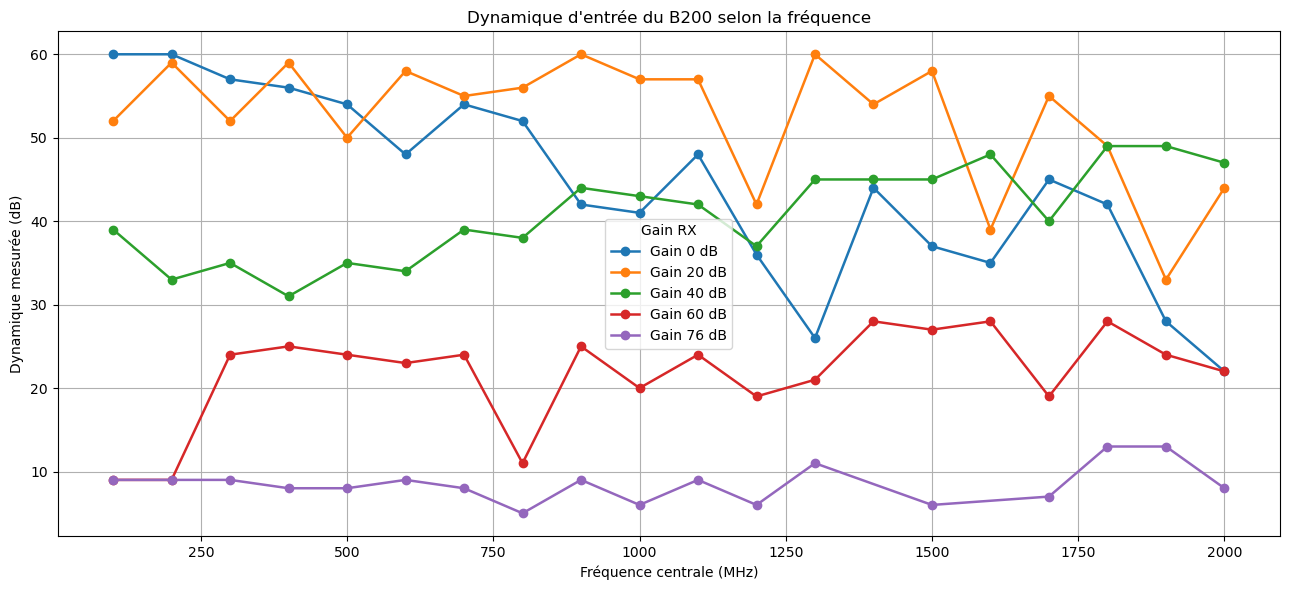

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/dynamic_range_vs_frequency.png


In [8]:
plt.figure(figsize=(13, 6))

gains = sorted(
    summary_df[SUMMARY_GAIN_COL].dropna().unique()
)

for gain_db in gains:
    gain_data = summary_df[
        np.isclose(
            summary_df[SUMMARY_GAIN_COL],
            gain_db,
        )
    ].dropna(subset=[SUMMARY_DYNAMIC_COL])

    plt.plot(
        gain_data[SUMMARY_FREQ_COL],
        gain_data[SUMMARY_DYNAMIC_COL],
        marker="o",
        linewidth=1.8,
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Dynamique d'entrée du B200 selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Dynamique mesurée (dB)")
plt.grid(True)
plt.legend(title="Gain RX")
plt.tight_layout()

output_path = PLOTS_DIR / "dynamic_range_vs_frequency.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

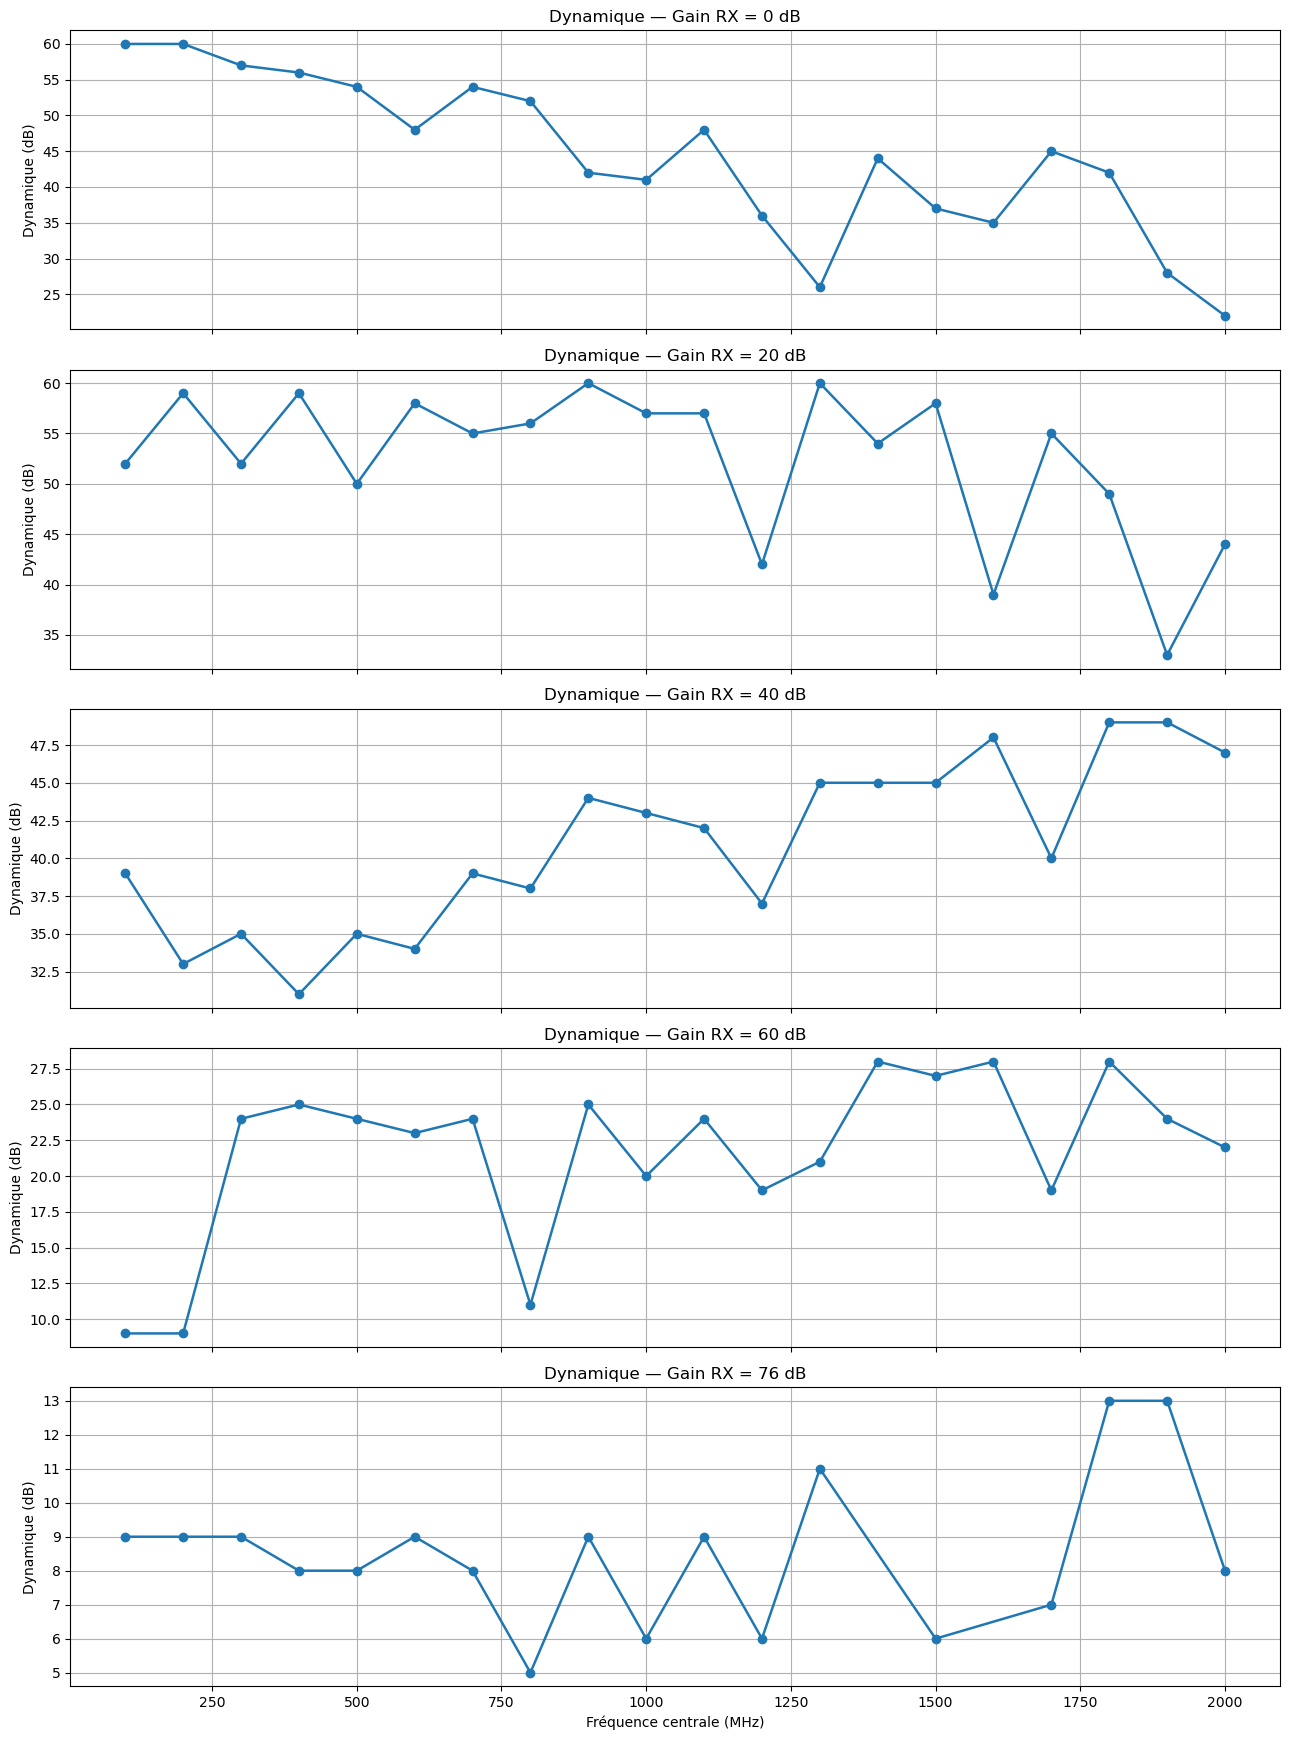

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/dynamic_range_subplots_by_gain.png


In [9]:
gains = sorted(
    summary_df[SUMMARY_GAIN_COL].dropna().unique()
)

figure, axes = plt.subplots(
    len(gains),
    1,
    figsize=(13, 3.5 * len(gains)),
    sharex=True,
)

if len(gains) == 1:
    axes = [axes]

for axis, gain_db in zip(axes, gains):
    gain_data = summary_df[
        np.isclose(
            summary_df[SUMMARY_GAIN_COL],
            gain_db,
        )
    ].dropna(subset=[SUMMARY_DYNAMIC_COL])

    axis.plot(
        gain_data[SUMMARY_FREQ_COL],
        gain_data[SUMMARY_DYNAMIC_COL],
        marker="o",
        linewidth=1.8,
    )

    axis.set_title(
        f"Dynamique — Gain RX = {gain_db:.0f} dB"
    )
    axis.set_ylabel("Dynamique (dB)")
    axis.grid(True)

axes[-1].set_xlabel("Fréquence centrale (MHz)")

plt.tight_layout()

output_path = PLOTS_DIR / "dynamic_range_subplots_by_gain.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

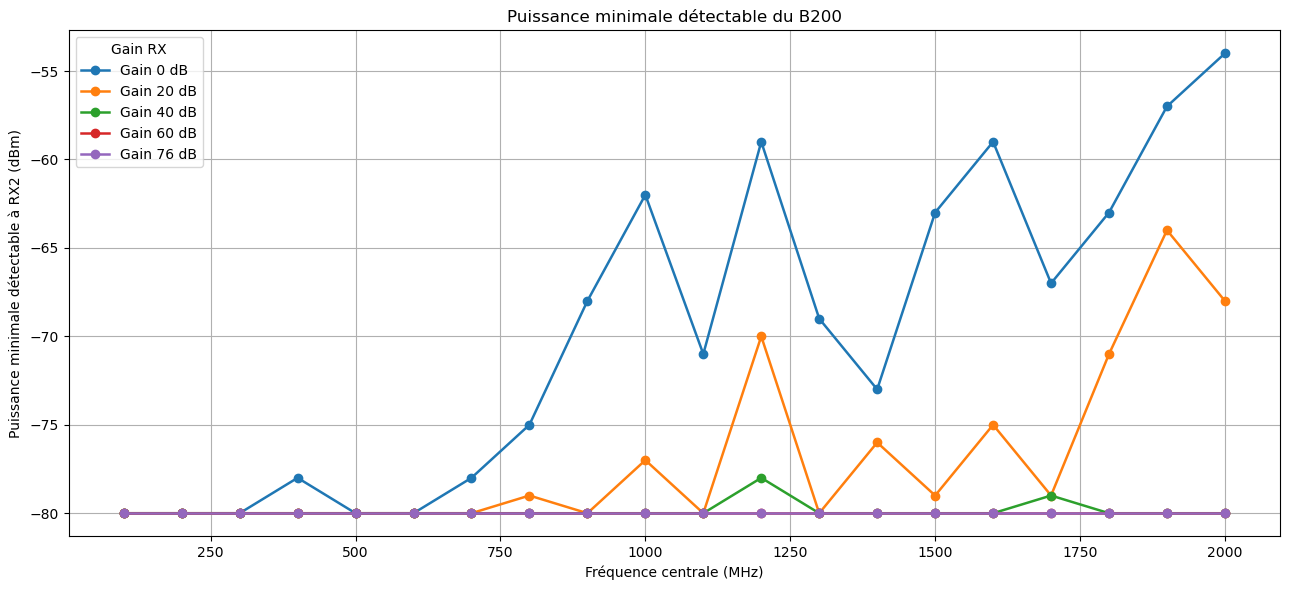

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/minimum_detectable_power.png


In [10]:
plt.figure(figsize=(13, 6))

for gain_db in gains:
    gain_data = summary_df[
        np.isclose(
            summary_df[SUMMARY_GAIN_COL],
            gain_db,
        )
    ].dropna(subset=[SUMMARY_PMIN_COL])

    plt.plot(
        gain_data[SUMMARY_FREQ_COL],
        gain_data[SUMMARY_PMIN_COL],
        marker="o",
        linewidth=1.8,
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Puissance minimale détectable du B200")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Puissance minimale détectable à RX2 (dBm)")
plt.grid(True)
plt.legend(title="Gain RX")
plt.tight_layout()

output_path = PLOTS_DIR / "minimum_detectable_power.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

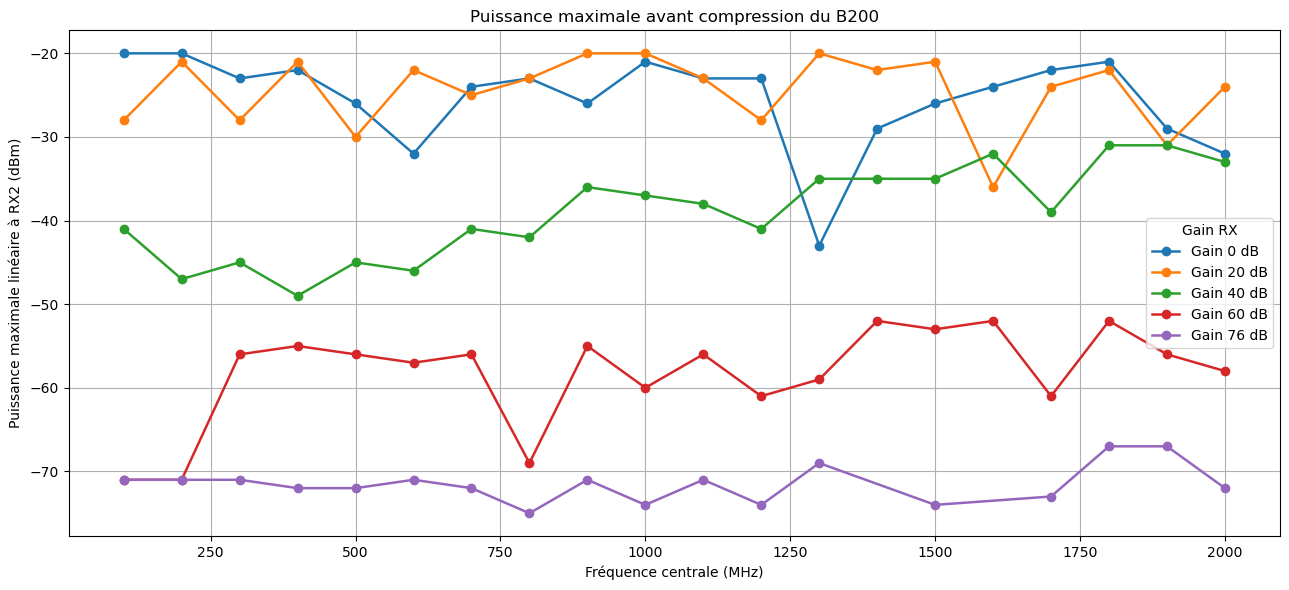

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/maximum_linear_power.png


In [11]:
plt.figure(figsize=(13, 6))

for gain_db in gains:
    gain_data = summary_df[
        np.isclose(
            summary_df[SUMMARY_GAIN_COL],
            gain_db,
        )
    ].dropna(subset=[SUMMARY_PMAX_COL])

    plt.plot(
        gain_data[SUMMARY_FREQ_COL],
        gain_data[SUMMARY_PMAX_COL],
        marker="o",
        linewidth=1.8,
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Puissance maximale avant compression du B200")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Puissance maximale linéaire à RX2 (dBm)")
plt.grid(True)
plt.legend(title="Gain RX")
plt.tight_layout()

output_path = PLOTS_DIR / "maximum_linear_power.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

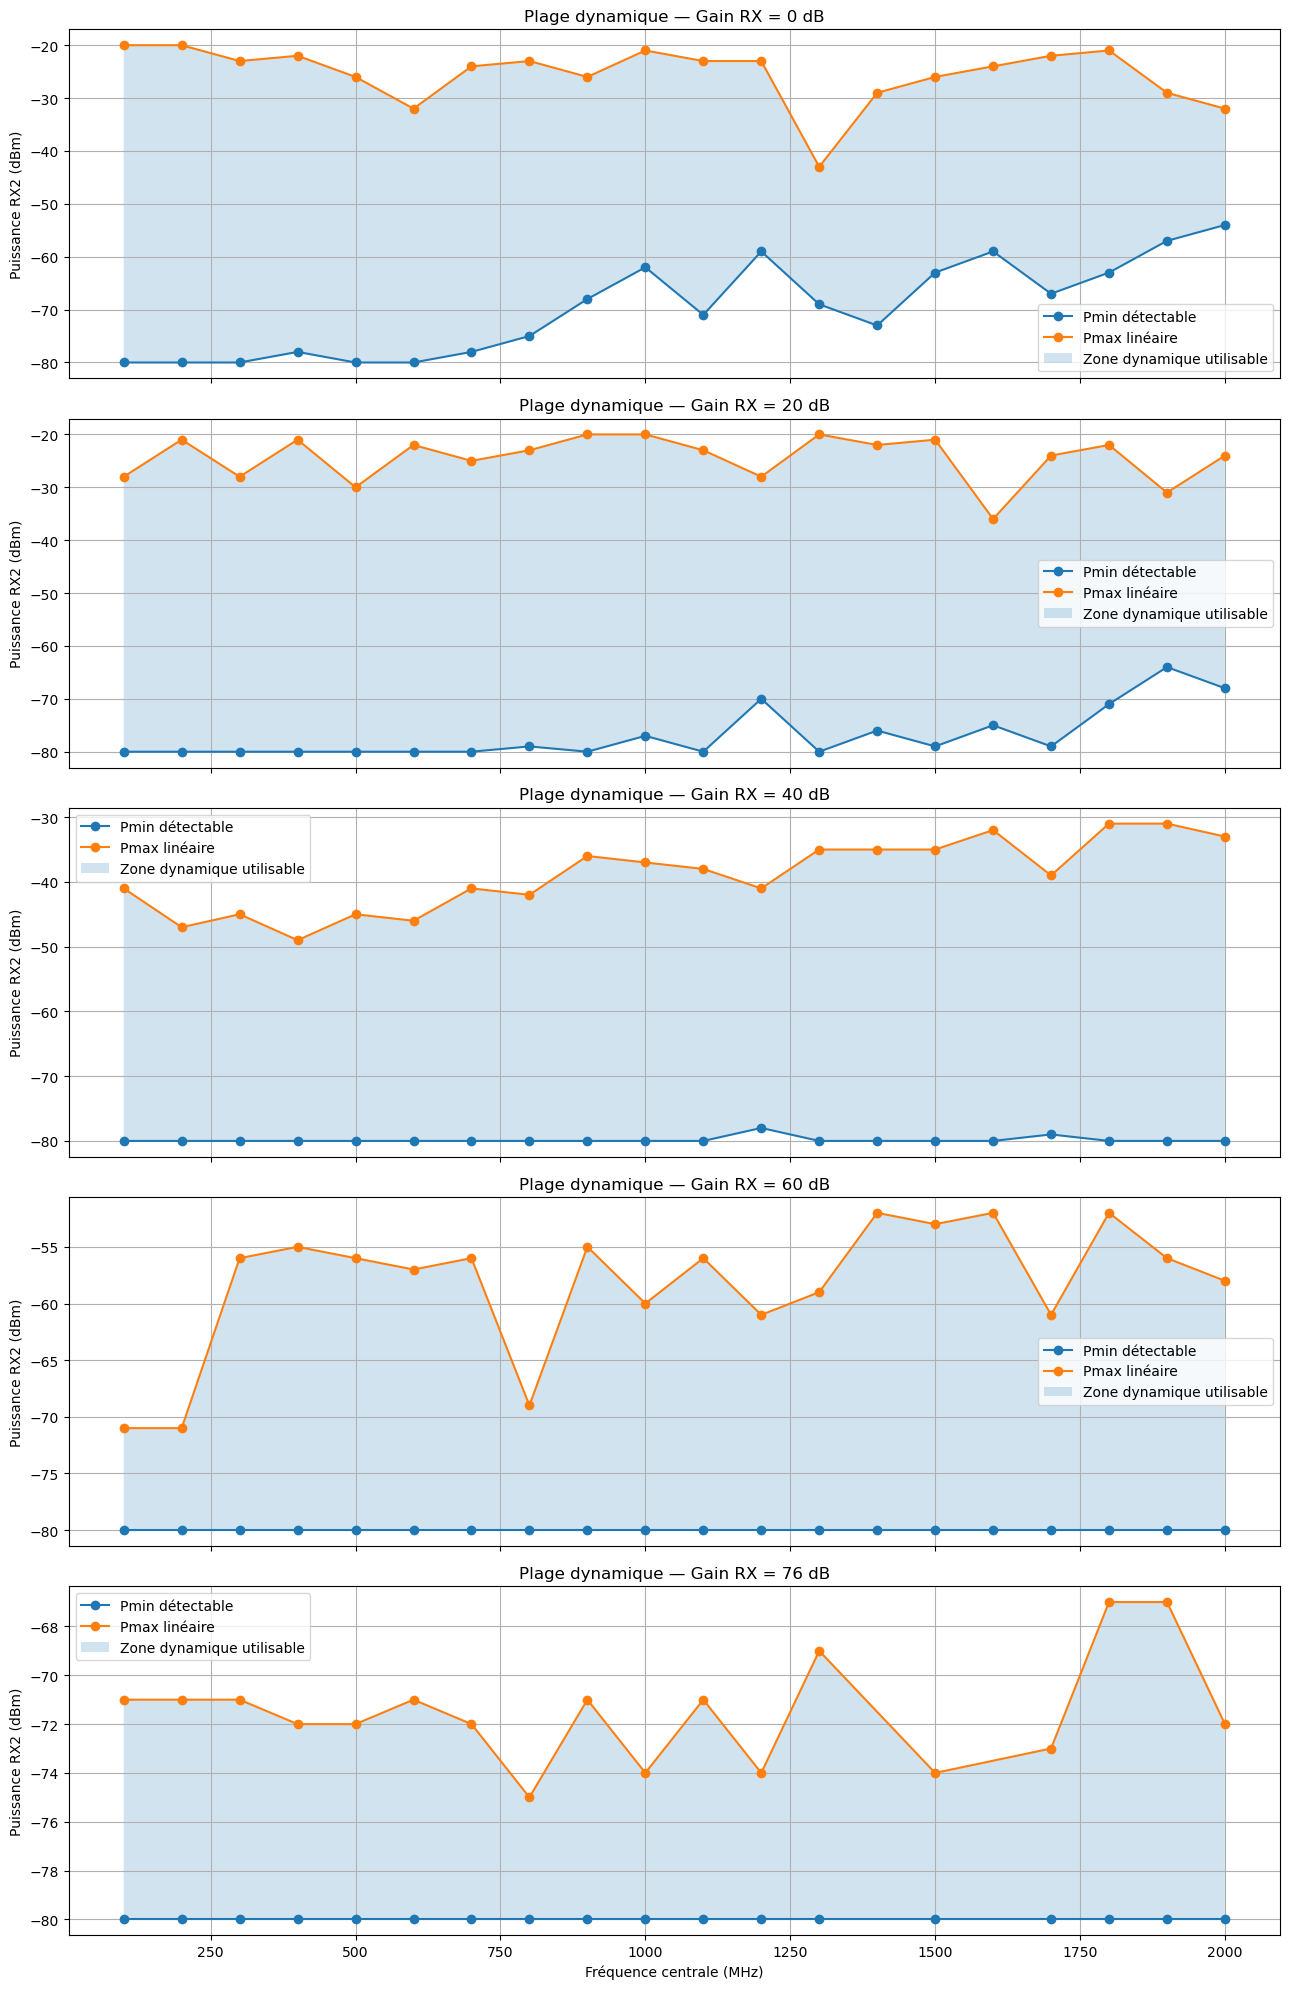

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/usable_input_range_by_gain.png


In [12]:
figure, axes = plt.subplots(
    len(gains),
    1,
    figsize=(13, 4 * len(gains)),
    sharex=True,
)

if len(gains) == 1:
    axes = [axes]

for axis, gain_db in zip(axes, gains):
    gain_data = summary_df[
        np.isclose(
            summary_df[SUMMARY_GAIN_COL],
            gain_db,
        )
    ].dropna(
        subset=[
            SUMMARY_PMIN_COL,
            SUMMARY_PMAX_COL,
        ]
    )

    x = gain_data[SUMMARY_FREQ_COL].to_numpy()
    pmin = gain_data[SUMMARY_PMIN_COL].to_numpy()
    pmax = gain_data[SUMMARY_PMAX_COL].to_numpy()

    axis.plot(
        x,
        pmin,
        marker="o",
        label="Pmin détectable",
    )

    axis.plot(
        x,
        pmax,
        marker="o",
        label="Pmax linéaire",
    )

    axis.fill_between(
        x,
        pmin,
        pmax,
        alpha=0.2,
        label="Zone dynamique utilisable",
    )

    axis.set_title(
        f"Plage dynamique — Gain RX = {gain_db:.0f} dB"
    )
    axis.set_ylabel("Puissance RX2 (dBm)")
    axis.grid(True)
    axis.legend()

axes[-1].set_xlabel("Fréquence centrale (MHz)")

plt.tight_layout()

output_path = PLOTS_DIR / "usable_input_range_by_gain.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

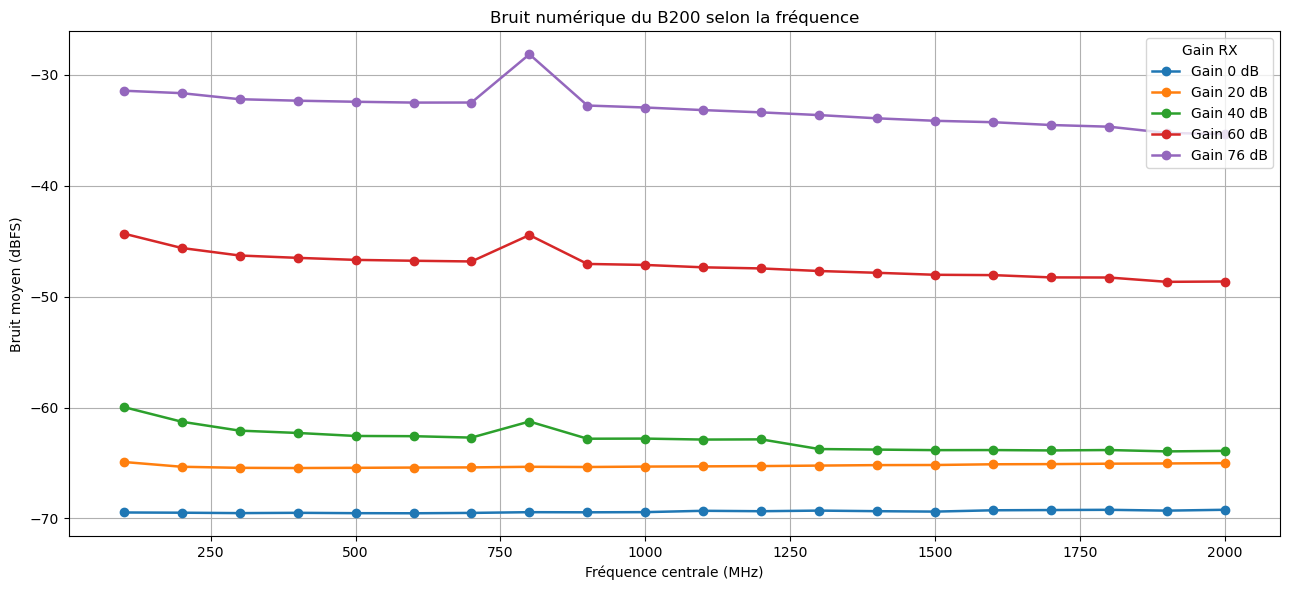

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/noise_floor_dbfs.png


In [13]:
plt.figure(figsize=(13, 6))

for gain_db in gains:
    gain_data = summary_df[
        np.isclose(
            summary_df[SUMMARY_GAIN_COL],
            gain_db,
        )
    ].dropna(subset=[SUMMARY_NOISE_DBFS_COL])

    plt.plot(
        gain_data[SUMMARY_FREQ_COL],
        gain_data[SUMMARY_NOISE_DBFS_COL],
        marker="o",
        linewidth=1.8,
        label=f"Gain {gain_db:.0f} dB",
    )

plt.title("Bruit numérique du B200 selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Bruit moyen (dBFS)")
plt.grid(True)
plt.legend(title="Gain RX")
plt.tight_layout()

output_path = PLOTS_DIR / "noise_floor_dbfs.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

In [14]:
if SUMMARY_NOISE_DBM_COL is None:
    print(
        "Le fichier résumé ne contient pas de colonne "
        "de bruit converti en dBm."
    )
else:
    plt.figure(figsize=(13, 6))

    for gain_db in gains:
        gain_data = summary_df[
            np.isclose(
                summary_df[SUMMARY_GAIN_COL],
                gain_db,
            )
        ].dropna(subset=[SUMMARY_NOISE_DBM_COL])

        plt.plot(
            gain_data[SUMMARY_FREQ_COL],
            gain_data[SUMMARY_NOISE_DBM_COL],
            marker="o",
            linewidth=1.8,
            label=f"Gain {gain_db:.0f} dB",
        )

    plt.title("Bruit d'entrée équivalent du B200")
    plt.xlabel("Fréquence centrale (MHz)")
    plt.ylabel("Bruit équivalent à RX2 (dBm)")
    plt.grid(True)
    plt.legend(title="Gain RX")
    plt.tight_layout()

    output_path = PLOTS_DIR / "noise_floor_dbm.png"
    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Graphe enregistré :", output_path)

Le fichier résumé ne contient pas de colonne de bruit converti en dBm.


In [15]:
dynamic_matrix = summary_df.pivot_table(
    index=SUMMARY_GAIN_COL,
    columns=SUMMARY_FREQ_COL,
    values=SUMMARY_DYNAMIC_COL,
    aggfunc="mean",
)

dynamic_matrix = dynamic_matrix.sort_index()
dynamic_matrix = dynamic_matrix.sort_index(axis=1)

display(dynamic_matrix.round(2))

frequency_mhz,100.0,200.0,300.0,400.0,500.0,600.0,700.0,800.0,900.0,1000.0,1100.0,1200.0,1300.0,1400.0,1500.0,1600.0,1700.0,1800.0,1900.0,2000.0
gain_db,,,,,,,,,,,,,,,,,,,,
0.0,60.0,60.0,57.0,56.0,54.0,48.0,54.0,52.0,42.0,41.0,48.0,36.0,26.0,44.0,37.0,35.0,45.0,42.0,28.0,22.0
20.0,52.0,59.0,52.0,59.0,50.0,58.0,55.0,56.0,60.0,57.0,57.0,42.0,60.0,54.0,58.0,39.0,55.0,49.0,33.0,44.0
40.0,39.0,33.0,35.0,31.0,35.0,34.0,39.0,38.0,44.0,43.0,42.0,37.0,45.0,45.0,45.0,48.0,40.0,49.0,49.0,47.0
60.0,9.0,9.0,24.0,25.0,24.0,23.0,24.0,11.0,25.0,20.0,24.0,19.0,21.0,28.0,27.0,28.0,19.0,28.0,24.0,22.0
76.0,9.0,9.0,9.0,8.0,8.0,9.0,8.0,5.0,9.0,6.0,9.0,6.0,11.0,NaN,6.0,NaN,7.0,13.0,13.0,8.0


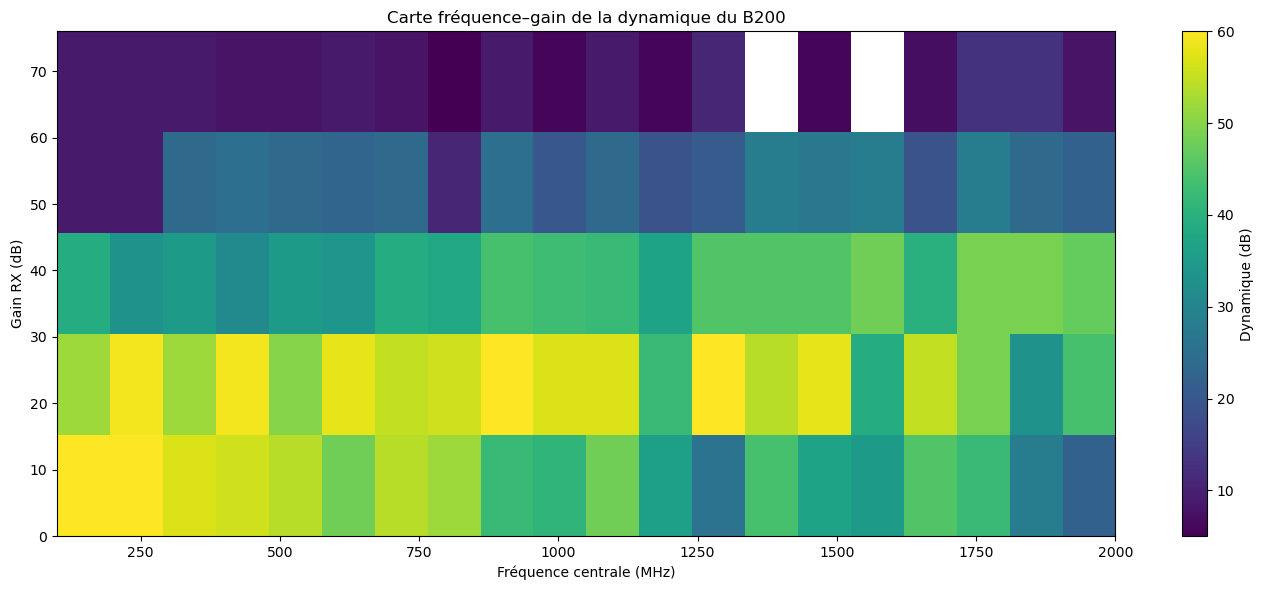

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/dynamic_range_heatmap.png


In [16]:
frequency_values = dynamic_matrix.columns.to_numpy(dtype=float)
gain_values = dynamic_matrix.index.to_numpy(dtype=float)
dynamic_values = dynamic_matrix.to_numpy(dtype=float)

plt.figure(figsize=(14, 6))

image = plt.imshow(
    dynamic_values,
    aspect="auto",
    origin="lower",
    extent=[
        frequency_values.min(),
        frequency_values.max(),
        gain_values.min(),
        gain_values.max(),
    ],
)

plt.colorbar(
    image,
    label="Dynamique (dB)",
)

plt.title("Carte fréquence–gain de la dynamique du B200")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Gain RX (dB)")
plt.tight_layout()

output_path = PLOTS_DIR / "dynamic_range_heatmap.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

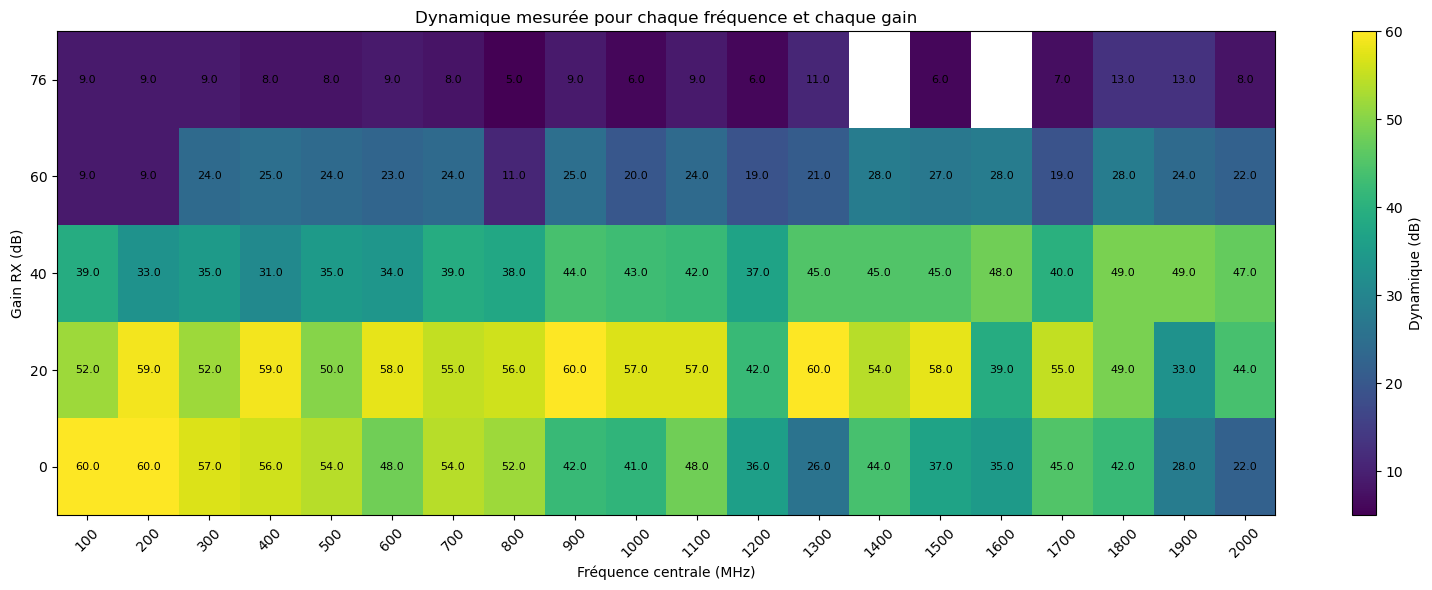

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/dynamic_range_heatmap_values.png


In [17]:
plt.figure(figsize=(16, 6))

image = plt.imshow(
    dynamic_values,
    aspect="auto",
    origin="lower",
)

plt.colorbar(
    image,
    label="Dynamique (dB)",
)

plt.xticks(
    ticks=np.arange(len(frequency_values)),
    labels=[
        f"{frequency:.0f}"
        for frequency in frequency_values
    ],
    rotation=45,
)

plt.yticks(
    ticks=np.arange(len(gain_values)),
    labels=[
        f"{gain:.0f}"
        for gain in gain_values
    ],
)

for row_index in range(dynamic_values.shape[0]):
    for column_index in range(dynamic_values.shape[1]):
        value = dynamic_values[row_index, column_index]

        if np.isfinite(value):
            plt.text(
                column_index,
                row_index,
                f"{value:.1f}",
                ha="center",
                va="center",
                fontsize=8,
            )

plt.title("Dynamique mesurée pour chaque fréquence et chaque gain")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Gain RX (dB)")
plt.tight_layout()

output_path = PLOTS_DIR / "dynamic_range_heatmap_values.png"
plt.savefig(output_path, dpi=220)
plt.show()

print("Graphe enregistré :", output_path)

In [18]:
statistics_by_gain = (
    summary_df
    .groupby(SUMMARY_GAIN_COL)
    .agg(
        dynamique_moyenne_db=(
            SUMMARY_DYNAMIC_COL,
            "mean",
        ),
        dynamique_minimale_db=(
            SUMMARY_DYNAMIC_COL,
            "min",
        ),
        dynamique_maximale_db=(
            SUMMARY_DYNAMIC_COL,
            "max",
        ),
        pmin_moyenne_dbm=(
            SUMMARY_PMIN_COL,
            "mean",
        ),
        pmax_moyenne_dbm=(
            SUMMARY_PMAX_COL,
            "mean",
        ),
        nombre_points=(
            SUMMARY_DYNAMIC_COL,
            "count",
        ),
    )
    .reset_index()
)

statistics_by_gain = statistics_by_gain.round(
    {
        SUMMARY_GAIN_COL: 1,
        "dynamique_moyenne_db": 2,
        "dynamique_minimale_db": 2,
        "dynamique_maximale_db": 2,
        "pmin_moyenne_dbm": 2,
        "pmax_moyenne_dbm": 2,
    }
)

display(statistics_by_gain)

,gain_db,dynamique_moyenne_db,dynamique_minimale_db,dynamique_maximale_db,pmin_moyenne_dbm,pmax_moyenne_dbm,nombre_points
0,0.0,44.35,22.0,60.0,-69.80,-25.45,20
1,20.0,52.45,33.0,60.0,-76.90,-24.45,20
2,40.0,40.90,31.0,49.0,-79.85,-38.95,20
3,60.0,21.70,9.0,28.0,-80.00,-58.30,20
4,76.0,8.50,5.0,13.0,-80.00,-71.50,18


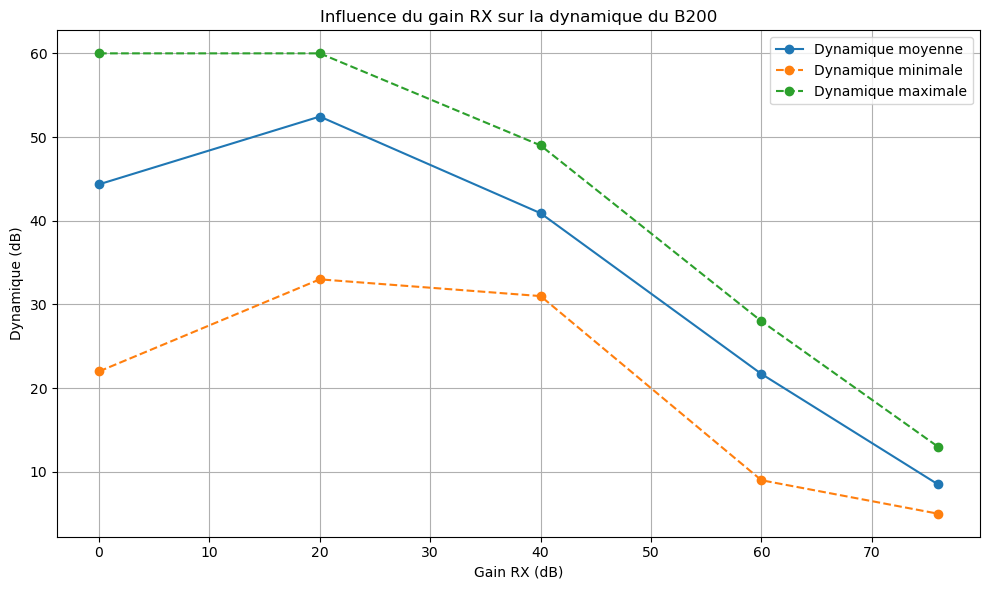

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/dynamic_statistics_by_gain.png


In [19]:
plt.figure(figsize=(10, 6))

plt.plot(
    statistics_by_gain[SUMMARY_GAIN_COL],
    statistics_by_gain["dynamique_moyenne_db"],
    marker="o",
    label="Dynamique moyenne",
)

plt.plot(
    statistics_by_gain[SUMMARY_GAIN_COL],
    statistics_by_gain["dynamique_minimale_db"],
    marker="o",
    linestyle="--",
    label="Dynamique minimale",
)

plt.plot(
    statistics_by_gain[SUMMARY_GAIN_COL],
    statistics_by_gain["dynamique_maximale_db"],
    marker="o",
    linestyle="--",
    label="Dynamique maximale",
)

plt.title("Influence du gain RX sur la dynamique du B200")
plt.xlabel("Gain RX (dB)")
plt.ylabel("Dynamique (dB)")
plt.grid(True)
plt.legend()
plt.tight_layout()

output_path = PLOTS_DIR / "dynamic_statistics_by_gain.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

In [20]:
AGG_FREQ_COL = find_column(
    aggregated_df,
    ["frequency_mhz", "freq_mhz"],
)

AGG_GAIN_COL = find_column(
    aggregated_df,
    ["gain_db", "gain", "rx_gain_db"],
)

AGG_INPUT_COL = find_column(
    aggregated_df,
    [
        "input_rx2_dbm",      # <-- dans ton CSV
        "input_dbm",
        "input_power_dbm",
        "rx_input_dbm",
    ],
)

AGG_GENERATOR_COL = find_column(
    aggregated_df,
    [
        "generator_dbm",
    ],
    required=False,
)

AGG_ATTENUATION_COL = find_column(
    aggregated_df,
    [
        "attenuation_db",
    ],
    required=False,
)

AGG_DBFS_COL = find_column(
    aggregated_df,
    [
        "total_power_dbfs",    # <-- dans ton CSV
        "measured_dbfs",
        "mean_dbfs",
        "median_dbfs",
        "power_dbfs",
    ],
)

AGG_TONE_DBFS_COL = find_column(
    aggregated_df,
    [
        "tone_power_dbfs",     # <-- dans ton CSV
    ],
    required=False,
)

AGG_ESTIMATED_DBM_COL = find_column(
    aggregated_df,
    [
        "estimated_dbm",
        "measured_dbm",
        "converted_dbm",
    ],
    required=False,
)

AGG_ERROR_COL = find_column(
    aggregated_df,
    [
        "compression_db",      # <-- dans ton CSV
        "linearity_error_db",
        "error_db",
    ],
    required=False,
)

AGG_CLIP_COL = find_column(
    aggregated_df,
    [
        "clipping_fraction",
        "clip_fraction",
    ],
    required=False,
)

AGG_LINEAR_COL = find_column(
    aggregated_df,
    [
        "linear",
    ],
    required=False,
)

print("Fréquence     :", AGG_FREQ_COL)
print("Gain          :", AGG_GAIN_COL)
print("Entrée RX2    :", AGG_INPUT_COL)
print("Générateur    :", AGG_GENERATOR_COL)
print("Atténuation   :", AGG_ATTENUATION_COL)
print("dBFS total    :", AGG_DBFS_COL)
print("dBFS tone     :", AGG_TONE_DBFS_COL)
print("dBm estimé    :", AGG_ESTIMATED_DBM_COL)
print("Compression   :", AGG_ERROR_COL)
print("Clipping      :", AGG_CLIP_COL)
print("Linéaire      :", AGG_LINEAR_COL)

Fréquence     : frequency_mhz
Gain          : gain_db
Entrée RX2    : input_rx2_dbm
Générateur    : generator_dbm
Atténuation   : attenuation_db
dBFS total    : total_power_dbfs
dBFS tone     : tone_power_dbfs
dBm estimé    : None
Compression   : compression_db
Clipping      : clipping_fraction
Linéaire      : linear


In [21]:
aggregated_numeric_columns = [
    AGG_FREQ_COL,
    AGG_GAIN_COL,
    AGG_INPUT_COL,
    AGG_DBFS_COL,
]

for optional_column in [
    AGG_ESTIMATED_DBM_COL,
    AGG_ERROR_COL,
    AGG_CLIP_COL,
]:
    if optional_column is not None:
        aggregated_numeric_columns.append(optional_column)

for column in aggregated_numeric_columns:
    aggregated_df[column] = pd.to_numeric(
        aggregated_df[column],
        errors="coerce",
    )

In [22]:
SELECTED_FREQUENCY_MHZ = 1000.0
SELECTED_GAIN_DB = 40.0

case_df = aggregated_df[
    np.isclose(
        aggregated_df[AGG_FREQ_COL],
        SELECTED_FREQUENCY_MHZ,
    )
    &
    np.isclose(
        aggregated_df[AGG_GAIN_COL],
        SELECTED_GAIN_DB,
    )
].copy()

case_df = case_df.sort_values(AGG_INPUT_COL)

print("Nombre de points :", len(case_df))
display(case_df)

Nombre de points : 61


,frequency_hz,frequency_mhz,gain_db,input_rx2_dbm,generator_dbm,attenuation_db,total_power_dbfs,tone_power_dbfs,noise_total_dbfs,noise_tone_dbfs,median_snr_db,detection_probability,peak_amplitude,clipping_fraction,predicted_dbfs,compression_db,linear
2989,1.000000e+09,1000.0,40.0,-80.0,-20.0,60.0,-47.863024,-93.748685,-62.858832,-118.980415,25.218690,1.0,0.006636,0.000000,-98.979882,-5.231197,False
2990,1.000000e+09,1000.0,40.0,-79.0,-19.0,60.0,-46.891941,-96.627767,-62.858832,-118.980415,22.327309,1.0,0.006978,0.000000,-97.694640,-1.066873,False
2991,1.000000e+09,1000.0,40.0,-78.0,-18.0,60.0,-45.908439,-92.952133,-62.858832,-118.980415,26.017430,1.0,0.007583,0.000000,-96.409398,-3.457266,False
2992,1.000000e+09,1000.0,40.0,-77.0,-17.0,60.0,-44.927937,-99.735568,-62.858832,-118.980415,19.192860,1.0,0.008651,0.000000,-95.124157,4.611411,False
2993,1.000000e+09,1000.0,40.0,-76.0,-16.0,60.0,-43.943379,-94.264232,-62.858832,-118.980415,24.701497,1.0,0.008813,0.000000,-93.838915,0.425318,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3045,1.000000e+09,1000.0,40.0,-24.0,6.0,30.0,0.691992,-40.264342,-62.622987,-118.677689,78.413348,1.0,1.364070,0.920925,-27.006335,13.258007,False
3046,1.000000e+09,1000.0,40.0,-23.0,7.0,30.0,0.728391,-38.382016,-62.622987,-118.677689,80.220873,1.0,1.378101,0.940275,-25.721093,12.660923,False
3047,1.000000e+09,1000.0,40.0,-22.0,8.0,30.0,0.762505,-37.638656,-62.622987,-118.677689,80.618709,1.0,1.385704,0.953538,-24.435851,13.202805,False
3048,1.000000e+09,1000.0,40.0,-21.0,9.0,30.0,0.794573,-37.945431,-62.622987,-118.677689,80.695349,1.0,1.394055,0.959758,-23.150609,14.794822,False


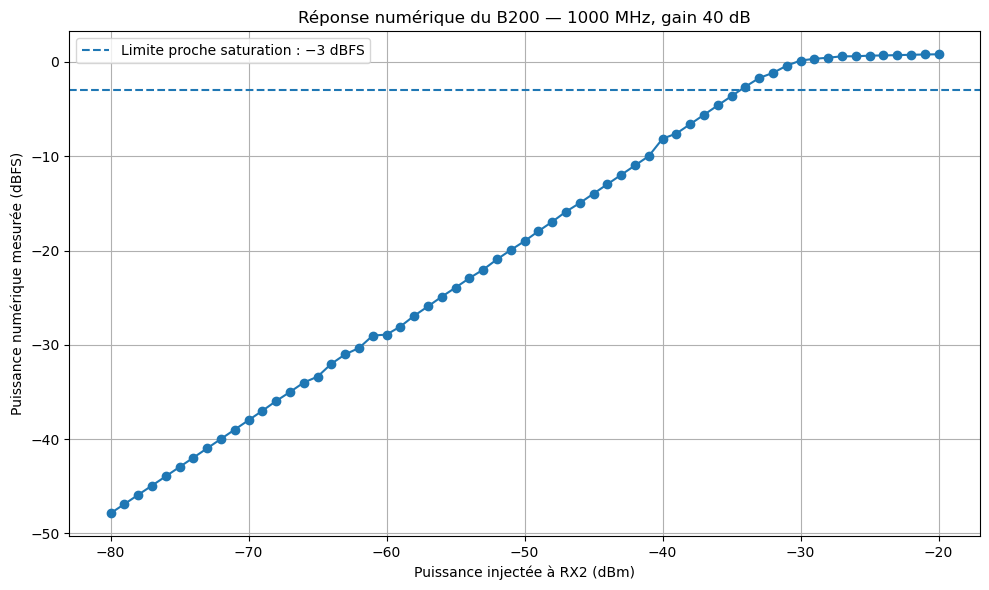

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/dbfs_response_1000MHz_gain40.png


In [23]:
plt.figure(figsize=(10, 6))

plt.plot(
    case_df[AGG_INPUT_COL],
    case_df[AGG_DBFS_COL],
    marker="o",
)

plt.axhline(
    -3.0,
    linestyle="--",
    label="Limite proche saturation : −3 dBFS",
)

plt.title(
    f"Réponse numérique du B200 — "
    f"{SELECTED_FREQUENCY_MHZ:.0f} MHz, "
    f"gain {SELECTED_GAIN_DB:.0f} dB"
)
plt.xlabel("Puissance injectée à RX2 (dBm)")
plt.ylabel("Puissance numérique mesurée (dBFS)")
plt.grid(True)
plt.legend()
plt.tight_layout()

output_path = (
    PLOTS_DIR
    / f"dbfs_response_{SELECTED_FREQUENCY_MHZ:.0f}MHz_"
      f"gain{SELECTED_GAIN_DB:.0f}.png"
)

plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

In [24]:
if AGG_ESTIMATED_DBM_COL is None:
    print(
        "Le CSV agrégé ne contient pas de puissance estimée en dBm."
    )
else:
    plt.figure(figsize=(8, 7))

    plt.plot(
        case_df[AGG_INPUT_COL],
        case_df[AGG_ESTIMATED_DBM_COL],
        marker="o",
        label="Puissance estimée",
    )

    minimum_value = min(
        case_df[AGG_INPUT_COL].min(),
        case_df[AGG_ESTIMATED_DBM_COL].min(),
    )

    maximum_value = max(
        case_df[AGG_INPUT_COL].max(),
        case_df[AGG_ESTIMATED_DBM_COL].max(),
    )

    plt.plot(
        [minimum_value, maximum_value],
        [minimum_value, maximum_value],
        linestyle="--",
        label="Réponse idéale",
    )

    plt.title(
        f"Linéarité du B200 — "
        f"{SELECTED_FREQUENCY_MHZ:.0f} MHz, "
        f"gain {SELECTED_GAIN_DB:.0f} dB"
    )
    plt.xlabel("Puissance réellement injectée à RX2 (dBm)")
    plt.ylabel("Puissance estimée avec calibration (dBm)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    output_path = (
        PLOTS_DIR
        / f"linearity_{SELECTED_FREQUENCY_MHZ:.0f}MHz_"
          f"gain{SELECTED_GAIN_DB:.0f}.png"
    )

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Graphe enregistré :", output_path)

Le CSV agrégé ne contient pas de puissance estimée en dBm.


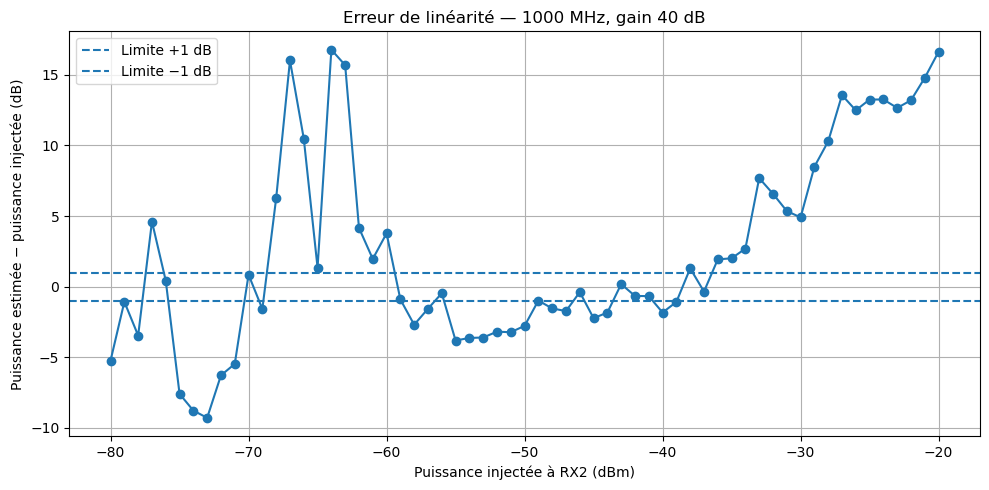

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/linearity_error_1000MHz_gain40.png


In [25]:
if AGG_ERROR_COL is None:
    if AGG_ESTIMATED_DBM_COL is not None:
        case_df["calculated_error_db"] = (
            case_df[AGG_ESTIMATED_DBM_COL]
            - case_df[AGG_INPUT_COL]
        )
        error_column = "calculated_error_db"
    else:
        error_column = None
else:
    error_column = AGG_ERROR_COL


if error_column is None:
    print("Impossible de calculer l'erreur de linéarité.")
else:
    plt.figure(figsize=(10, 5))

    plt.plot(
        case_df[AGG_INPUT_COL],
        case_df[error_column],
        marker="o",
    )

    plt.axhline(
        1.0,
        linestyle="--",
        label="Limite +1 dB",
    )

    plt.axhline(
        -1.0,
        linestyle="--",
        label="Limite −1 dB",
    )

    plt.title(
        f"Erreur de linéarité — "
        f"{SELECTED_FREQUENCY_MHZ:.0f} MHz, "
        f"gain {SELECTED_GAIN_DB:.0f} dB"
    )
    plt.xlabel("Puissance injectée à RX2 (dBm)")
    plt.ylabel("Puissance estimée − puissance injectée (dB)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()

    output_path = (
        PLOTS_DIR
        / f"linearity_error_{SELECTED_FREQUENCY_MHZ:.0f}MHz_"
          f"gain{SELECTED_GAIN_DB:.0f}.png"
    )

    plt.savefig(output_path, dpi=200)
    plt.show()

    print("Graphe enregistré :", output_path)

In [26]:
selected_columns = {
    SUMMARY_FREQ_COL: "Fréquence (MHz)",
    SUMMARY_GAIN_COL: "Gain RX (dB)",
    SUMMARY_NOISE_DBFS_COL: "Bruit (dBFS)",
    SUMMARY_PMIN_COL: "Pmin détectable (dBm)",
    SUMMARY_PMAX_COL: "Pmax linéaire (dBm)",
    SUMMARY_DYNAMIC_COL: "Dynamique (dB)",
}

if SUMMARY_NOISE_DBM_COL is not None:
    selected_columns[
        SUMMARY_NOISE_DBM_COL
    ] = "Bruit équivalent (dBm)"

if SUMMARY_ATTENUATION_COL is not None:
    selected_columns[
        SUMMARY_ATTENUATION_COL
    ] = "Atténuation (dB)"

if SUMMARY_STATUS_COL is not None:
    selected_columns[
        SUMMARY_STATUS_COL
    ] = "État"

final_table = (
    summary_df[list(selected_columns.keys())]
    .rename(columns=selected_columns)
    .copy()
)

numeric_final_columns = [
    column
    for column in final_table.columns
    if column != "État"
]

for column in numeric_final_columns:
    final_table[column] = pd.to_numeric(
        final_table[column],
        errors="coerce",
    )

display(final_table.round(2))

,Fréquence (MHz),Gain RX (dB),Bruit (dBFS),Pmin détectable (dBm),Pmax linéaire (dBm),Dynamique (dB)
0,100.0,0.0,-69.46,-80.0,-20.0,60.0
1,200.0,0.0,-69.48,-80.0,-20.0,60.0
2,300.0,0.0,-69.52,-80.0,-23.0,57.0
3,400.0,0.0,-69.49,-78.0,-22.0,56.0
4,500.0,0.0,-69.52,-80.0,-26.0,54.0
...,...,...,...,...,...,...
95,1600.0,76.0,-34.27,-80.0,NaN,NaN
96,1700.0,76.0,-34.52,-80.0,-73.0,7.0
97,1800.0,76.0,-34.67,-80.0,-67.0,13.0
98,1900.0,76.0,-35.24,-80.0,-67.0,13.0


In [27]:
FINAL_TABLE_FILE = (
    BASE_DIR
    / "dynamic_range_final_table.csv"
)

final_table.to_csv(
    FINAL_TABLE_FILE,
    index=False,
)

print("Tableau final enregistré :")
print(FINAL_TABLE_FILE)

Tableau final enregistré :
/home/yousef/b200_dynamic_range_complete/dynamic_range_final_table.csv


In [28]:
best_gain_by_frequency = (
    summary_df
    .dropna(subset=[SUMMARY_DYNAMIC_COL])
    .loc[
        summary_df
        .dropna(subset=[SUMMARY_DYNAMIC_COL])
        .groupby(SUMMARY_FREQ_COL)[SUMMARY_DYNAMIC_COL]
        .idxmax()
    ]
    [
        [
            SUMMARY_FREQ_COL,
            SUMMARY_GAIN_COL,
            SUMMARY_PMIN_COL,
            SUMMARY_PMAX_COL,
            SUMMARY_DYNAMIC_COL,
        ]
    ]
    .sort_values(SUMMARY_FREQ_COL)
    .reset_index(drop=True)
)

best_gain_by_frequency.columns = [
    "Fréquence (MHz)",
    "Meilleur gain (dB)",
    "Pmin (dBm)",
    "Pmax (dBm)",
    "Dynamique maximale (dB)",
]

display(best_gain_by_frequency.round(2))

,Fréquence (MHz),Meilleur gain (dB),Pmin (dBm),Pmax (dBm),Dynamique maximale (dB)
0,100.0,0.0,-80.0,-20.0,60.0
1,200.0,0.0,-80.0,-20.0,60.0
2,300.0,0.0,-80.0,-23.0,57.0
3,400.0,20.0,-80.0,-21.0,59.0
4,500.0,0.0,-80.0,-26.0,54.0
5,600.0,20.0,-80.0,-22.0,58.0
6,700.0,20.0,-80.0,-25.0,55.0
7,800.0,20.0,-79.0,-23.0,56.0
8,900.0,20.0,-80.0,-20.0,60.0
9,1000.0,20.0,-77.0,-20.0,57.0


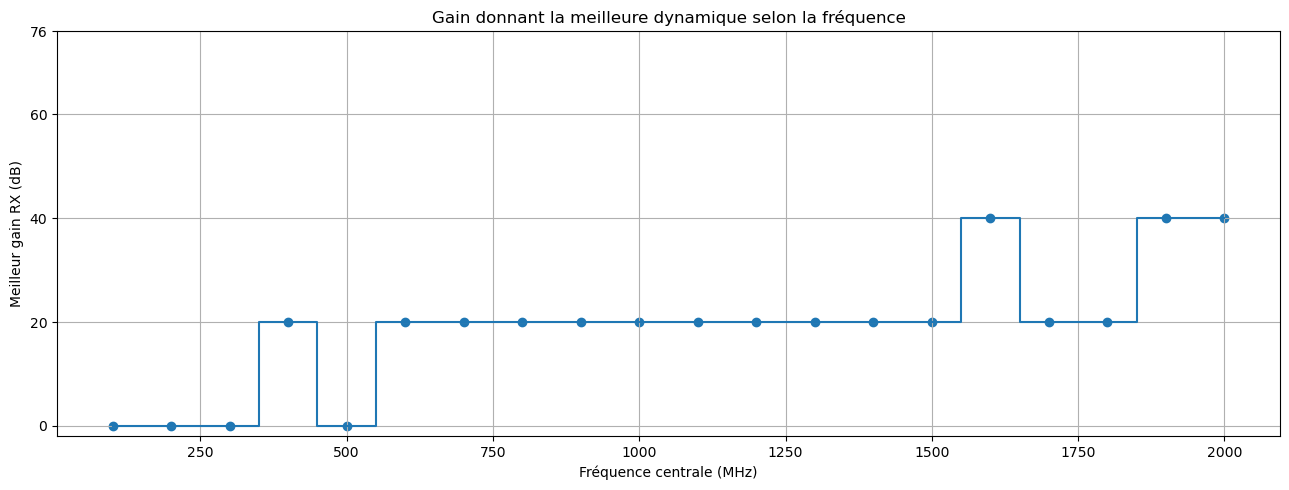

Graphe enregistré : /home/yousef/b200_dynamic_range_complete/plots_notebook/best_gain_vs_frequency.png


In [29]:
plt.figure(figsize=(13, 5))

plt.step(
    best_gain_by_frequency["Fréquence (MHz)"],
    best_gain_by_frequency["Meilleur gain (dB)"],
    where="mid",
)

plt.scatter(
    best_gain_by_frequency["Fréquence (MHz)"],
    best_gain_by_frequency["Meilleur gain (dB)"],
)

plt.title("Gain donnant la meilleure dynamique selon la fréquence")
plt.xlabel("Fréquence centrale (MHz)")
plt.ylabel("Meilleur gain RX (dB)")
plt.yticks(sorted(gains))
plt.grid(True)
plt.tight_layout()

output_path = PLOTS_DIR / "best_gain_vs_frequency.png"
plt.savefig(output_path, dpi=200)
plt.show()

print("Graphe enregistré :", output_path)

In [30]:
SELECTED_GAIN = 60

In [31]:
summary_gain = summary_df[
    summary_df["gain_db"] == SELECTED_GAIN
].copy()

agg_gain = aggregated_df[
    aggregated_df["gain_db"] == SELECTED_GAIN
].copy()

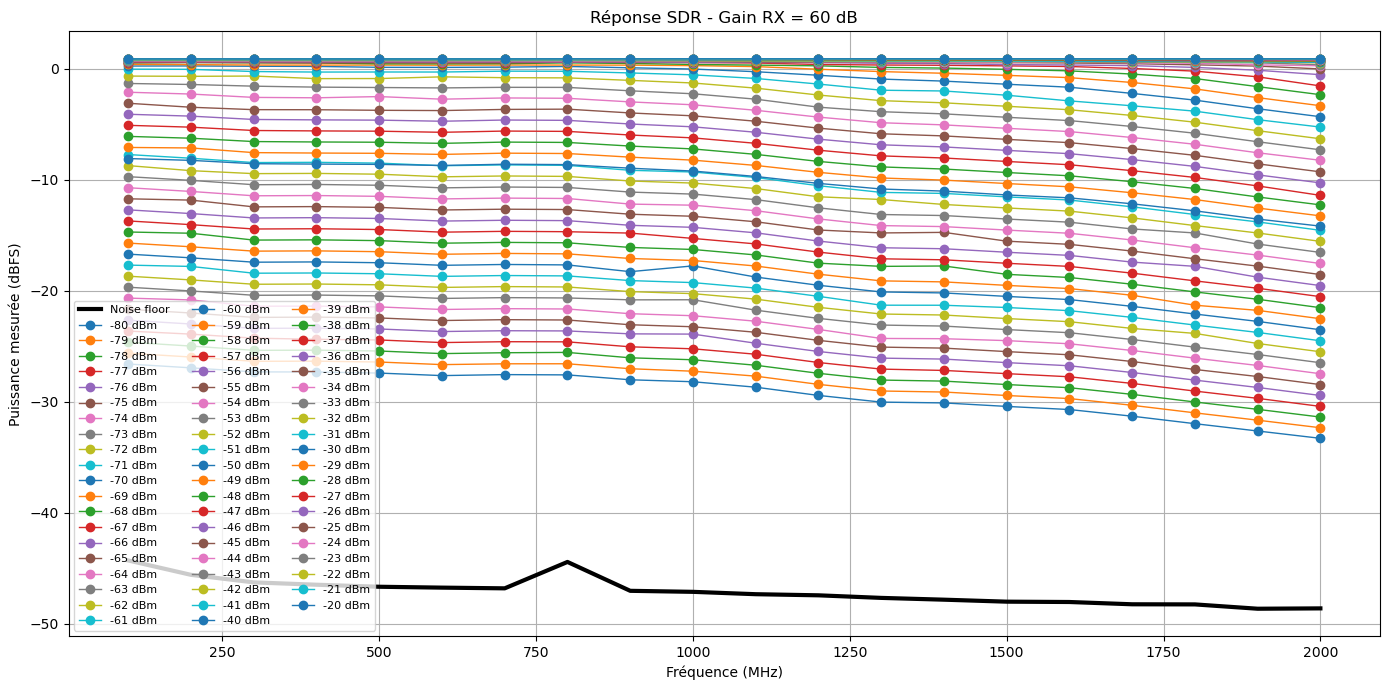

In [32]:
plt.figure(figsize=(14,7))

########################################################################
# Noise floor
########################################################################

plt.plot(
    summary_gain["frequency_mhz"],
    summary_gain["noise_total_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor",
)

########################################################################
# Courbes des puissances injectées
########################################################################

powers = sorted(agg_gain["input_rx2_dbm"].unique())

for p in powers:

    data = agg_gain[
        agg_gain["input_rx2_dbm"] == p
    ].sort_values("frequency_mhz")

    plt.plot(
        data["frequency_mhz"],
        data["total_power_dbfs"],
        marker="o",
        linewidth=1,
        label=f"{p:.0f} dBm",
    )

plt.grid(True)

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.title(
    f"Réponse SDR - Gain RX = {SELECTED_GAIN} dB"
)

plt.legend(
    ncol=3,
    fontsize=8
)

plt.tight_layout()

plt.show()

/tmp/ipykernel_30414/2017392807.py:52: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


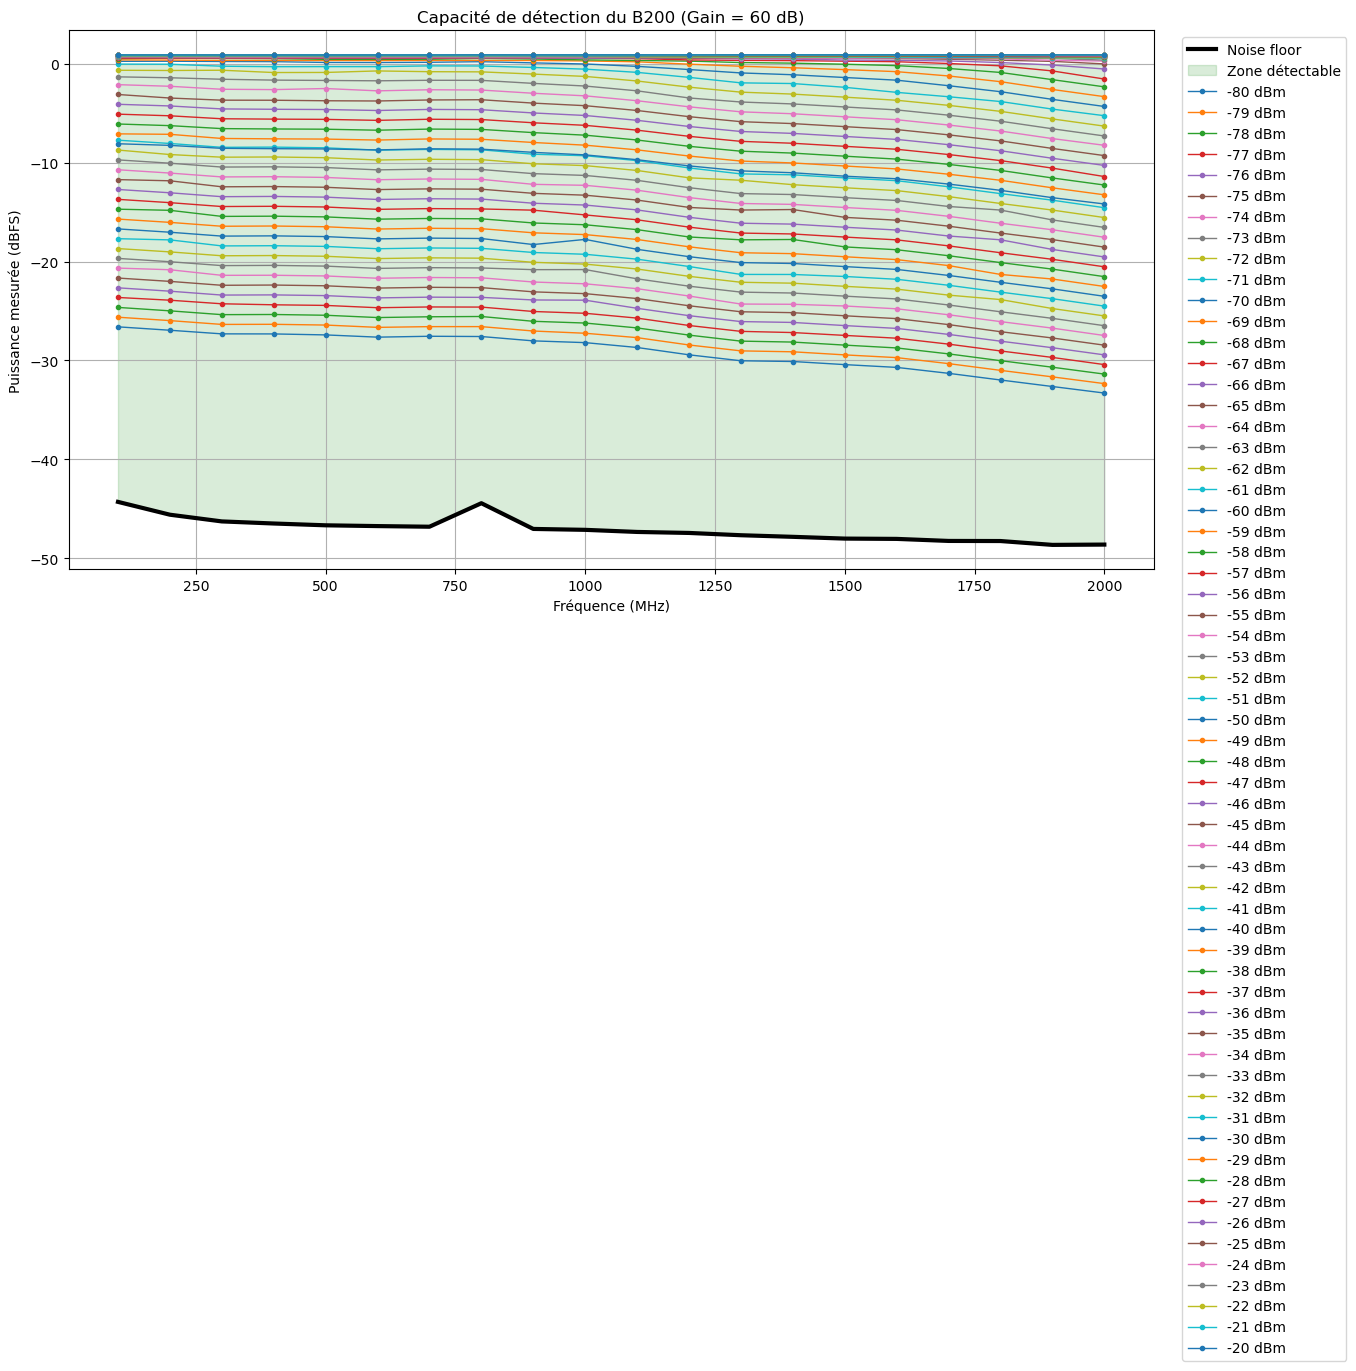

In [33]:
plt.figure(figsize=(14,7))

noise = summary_gain.sort_values("frequency_mhz")

plt.plot(
    noise["frequency_mhz"],
    noise["noise_total_dbfs"],
    color="black",
    linewidth=3,
    label="Noise floor",
)

plt.fill_between(
    noise["frequency_mhz"],
    noise["noise_total_dbfs"],
    0,
    color="green",
    alpha=0.15,
    label="Zone détectable",
)

powers = sorted(agg_gain["input_rx2_dbm"].unique())

for p in powers:

    data = agg_gain[
        agg_gain["input_rx2_dbm"] == p
    ].sort_values("frequency_mhz")

    plt.plot(
        data["frequency_mhz"],
        data["total_power_dbfs"],
        linewidth=1,
        marker=".",
        label=f"{p:.0f} dBm",
    )

plt.xlabel("Fréquence (MHz)")
plt.ylabel("Puissance mesurée (dBFS)")

plt.title(
    f"Capacité de détection du B200 (Gain = {SELECTED_GAIN} dB)"
)

plt.grid(True)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

plt.show()